Epoch 1/200, Train Loss: 1027448622.1355, Val Loss: 885739937.6453
Epoch 2/200, Train Loss: 662728638.6981, Val Loss: 499908167.6536
Epoch 3/200, Train Loss: 235508423.7720, Val Loss: 83570207.8592
Epoch 4/200, Train Loss: 33989549.9314, Val Loss: 8341061.7920
Epoch 5/200, Train Loss: 13488349.8334, Val Loss: 5970410.1659
Epoch 6/200, Train Loss: 12167059.6098, Val Loss: 8928795.2062
Epoch 7/200, Train Loss: 11545195.7915, Val Loss: 7724196.3310
Epoch 8/200, Train Loss: 11380718.5005, Val Loss: 13130782.4452
Epoch 9/200, Train Loss: 11034328.5672, Val Loss: 8985625.0208
Epoch 10/200, Train Loss: 10939799.1051, Val Loss: 12352900.8272
Epoch 11/200, Train Loss: 10294685.7292, Val Loss: 9700577.4510
Epoch 12/200, Train Loss: 10288516.0013, Val Loss: 5758908.8865
Epoch 13/200, Train Loss: 10115202.1753, Val Loss: 9404459.6922
Epoch 14/200, Train Loss: 10179676.5504, Val Loss: 9149121.6469
Epoch 15/200, Train Loss: 10218298.5359, Val Loss: 12333486.0110
Epoch 16/200, Train Loss: 10038607.33

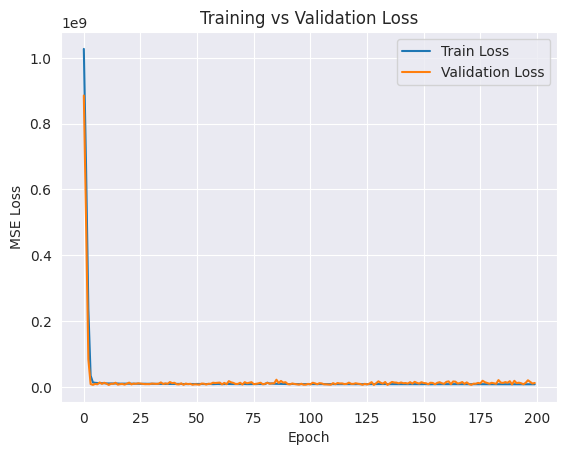

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pandas as pd

# ==== 1. Generate and preprocess data ====
df_train = pd.read_csv("transformedtest2.csv")
df_test = pd.read_csv("transformedtest2.csv")
n_features = len(df_train.columns) - 2

from sklearn.model_selection import train_test_split

X = df_train.drop(["Y", "ID"], axis=1)
y = df_train["Y"]
n_features = len(df_train.columns) -2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=99)
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, X_train_tensor), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_test_tensor, X_test_tensor), batch_size=16)

# ==== 2. Define the autoencoder ====
class Autoencoder(nn.Module):
    def __init__(self, n_inputs):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_inputs, n_inputs * 2),
            nn.BatchNorm1d(n_inputs * 2),
            nn.LeakyReLU(),
            nn.Linear(n_inputs * 2, n_inputs),
            nn.BatchNorm1d(n_inputs),
            nn.LeakyReLU(),
            nn.Linear(n_inputs, n_inputs)  # Bottleneck (no compression)
        )
        self.decoder = nn.Sequential(
            nn.Linear(n_inputs, n_inputs),
            nn.BatchNorm1d(n_inputs),
            nn.LeakyReLU(),
            nn.Linear(n_inputs, n_inputs * 2),
            nn.BatchNorm1d(n_inputs * 2),
            nn.LeakyReLU(),
            nn.Linear(n_inputs * 2, n_inputs)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# ==== 3. Train the model ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(n_features).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 200
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

# ==== 4. Plot losses ====
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()

# ==== 5. Save encoder ====
# Extract only the encoder
encoder = model.encoder
torch.save(encoder.state_dict(), 'encoder_no_compress.pth')
